TO DO
:analyze iris.csv
done!



---


 **DecisionTree Classification with Multiple Labels using Scikit-learn**


---



In [13]:
from sklearn import  datasets
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation

from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier



**Loading data**

In [14]:
#TO DO
iris = datasets.load_iris()
print(type(iris))
#print(iris)



<class 'sklearn.utils.Bunch'>


**Exploring the data**

In [15]:
#TO DO:
# print data(feature)shape
#X
print(iris.data.shape)
# print target(or label)shape
#y
print(iris.target_names)

# print the names of the features
print(iris.feature_names)

print(iris.target)

(150, 4)
['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


**Splitting the data**

In [16]:
#TO DO:
# Import train_test_split function
#from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size = 0.3, random_state=12 )

# Split dataset into training set and test set #hold-out with various splits #random_state
# 70% training and 30% test

In [17]:
#TO DO: check training dataset shape 
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(105, 4)
(45, 4)
(105,)
(45,)


**Model Generation**

In [18]:
#TO DO:
# Create Decision Tree classifer object
dt = DecisionTreeClassifier()

# Train Decision Tree Classifer
dt = dt.fit(X_train,y_train)


**Model visualization**

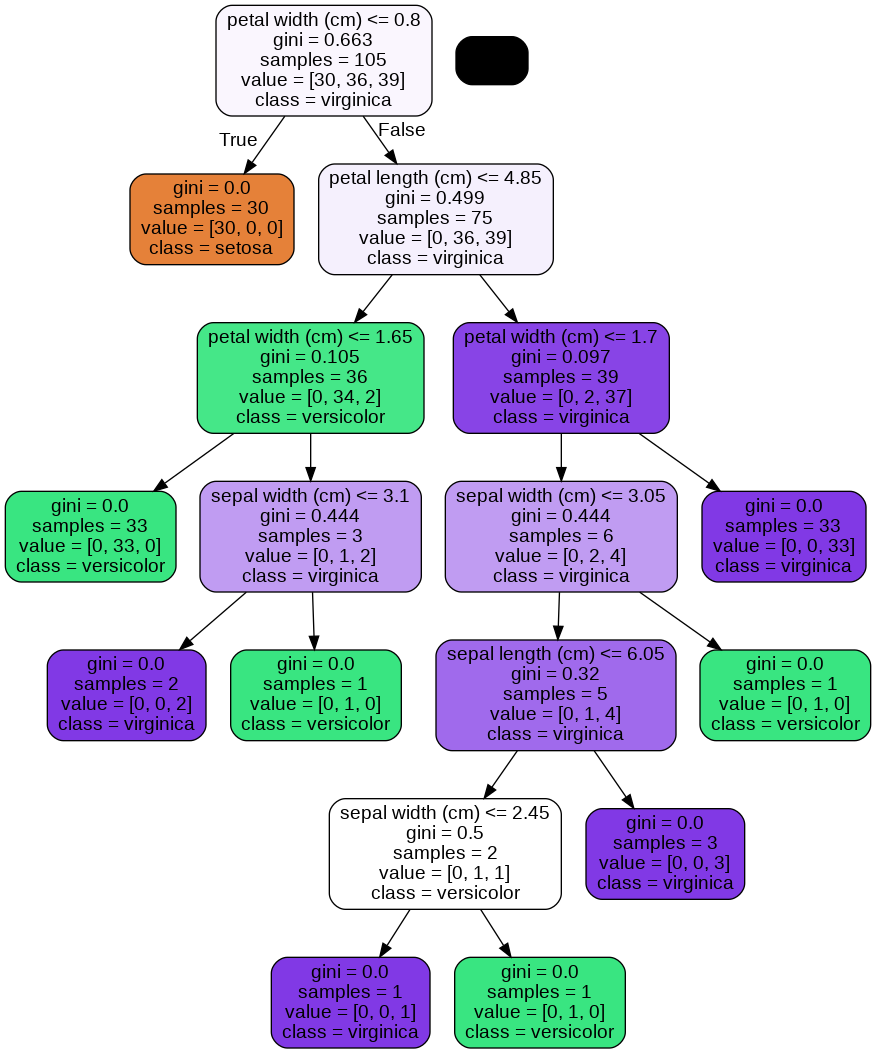

In [19]:
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image  
import pydotplus

dot_data = StringIO()
export_graphviz(dt,
            out_file =  dot_data,
            feature_names = list(iris.feature_names),
            class_names = iris.target_names,
            filled = True,
            rounded = True)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png('my_Tree_4.png')
Image(graph.create_png())
#Evenly distributed would be 1 – (1/# Classes).
#max_gini = 1- (1/len(iris.target_names))
#print(max_gini)

**Making predictions**

In [20]:
#TO DO:
# Making a Prediction On a New Set of samples
# N.B predict requires in input a list 
sample_one = X_test[0:2]
sample_one_pred = dt.predict(sample_one)

print(sample_one)
print(sample_one_pred)

print(f"The first sample most likely belongs to the {iris.target_names[sample_one_pred]} iris class.")

sample_two_pred = dt.predict([[1,5,2.6,1.5]])
print(sample_two_pred)
print(f"The second sample most likely belongs to the {iris.target_names[sample_two_pred]} iris class.")

#predict probability
sample_one_prob = dt.predict_proba(sample_one)
print(sample_one_prob)

[[5.  3.5 1.3 0.3]
 [6.3 2.5 5.  1.9]]
[0 2]
The first sample most likely belongs to the ['setosa' 'virginica'] iris class.
[1]
The second sample most likely belongs to the ['versicolor'] iris class.
[[1. 0. 0.]
 [0. 0. 1.]]


**Model evalution: accuracy**
TO DO:
how to evaluate?what is accuracy?

In [21]:
#Import scikit-learn metrics module for accuracy calculation
#Model Accuracy, how often is the classifier correct?

#Predict the response for test dataset
y_pred =dt.predict(X_test)
print(y_pred)

print("accuracy on test: ", metrics.accuracy_score(y_test, y_pred))

#Predict the response for train dataset
y_pred = dt.predict(X_train)
print("accuracy on train: ", metrics.accuracy_score(y_train, y_pred))

[0 2 0 1 2 2 2 0 2 0 1 0 0 0 1 2 2 1 0 2 0 1 2 1 0 2 2 1 0 0 0 1 2 0 2 0 1
 1 0 1 1 0 0 0 0]
accuracy on test:  0.9555555555555556
accuracy on train:  1.0


**Cross-validation**

In [22]:
#TO DO: import cross_val_score metric and perform cross validation
from sklearn.model_selection import cross_val_score

cross_val_score(dt, iris.data, iris.target, cv = 5)

#compute mean accuracy value

array([0.96666667, 0.96666667, 0.9       , 0.93333333, 1.        ])

**Confusion matrix and classification report**
explain confusion matrix from documentation

In [23]:
#TO DO: compute the confusion matrix
from sklearn.metrics import confusion_matrix
y_pred =dt.predict(X_test)
print(y_pred)
confusion_matrix(y_test,y_pred)



[0 2 0 1 2 2 2 0 2 0 1 0 0 0 1 2 2 1 0 2 0 1 2 1 0 2 2 1 0 0 0 1 2 0 2 0 1
 1 0 1 1 0 0 0 0]


array([[20,  0,  0],
       [ 0, 12,  2],
       [ 0,  0, 11]])

**Plotting the confusion matrix**

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


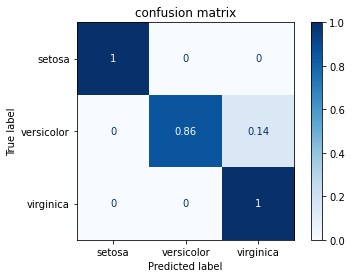

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import plot_confusion_matrix
# Plot confusion matrix
class_names = iris.target_names
title = "confusion matrix"
#for title, normalize in titles_options:
disp = plot_confusion_matrix(dt, X_test, y_test,
                                 display_labels=class_names,
                                 cmap=plt.cm.Blues,
                                 normalize="true") #normalize =None
disp.ax_.set_title(title)

#print(title)
#print(disp.confusion_matrix)

plt.show()